## MACHINE LEARNING ANALYSIS OF MESENCHYMAL STEM CELL BEHAVIOUR

**RESEARCH QUESTION**

Can the senescence state of a MSC stem cell be predicted based on its gene expression levels, and which biomarkers (genes) are the most determinant in this process?

**EXPLORATORY ANALYSIS AND DATA CLEANING**

In [1]:
import pandas as pd #herramienta estandar para manejar datos en formato tabla
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file='../data/GSE135401_series_matrix.txt.gz' 
#ruta_archivo='/Users/inesquinpar/Desktop/mesenchymal-stem-cell-ml/data/GSE135401_series_matrix.txt.gz' 
    #TODO: meter la ruta para cualquiera

raw_data=pd.read_csv(file, sep='\t', comment='!', index_col=0) #quitar el texto explicativo del inicio (empieza por !)
    #comment='!': pandas ignora el texto y va directo a los datos numericos

print('original dimensions:', raw_data.shape) #fil x col

raw_data.head() 
    #muestras en columnas (cada GSM es una cultivo biologico)
    #genes en filas (nivel de espresion de un gen) (ILMN: microarray Illumina)

original dimensions: (47322, 12)


,GSM4007684,GSM4007685,GSM4007686,GSM4007687,GSM4007688,GSM4007689,GSM4007690,GSM4007691,GSM4007692,GSM4007693,GSM4007694,GSM4007695
ID_REF,,,,,,,,,,,,
ILMN_1343291,24786.900000,23685.770000,25767.630000,23941.040000,24098.310000,24098.310000,25767.630000,22794.080000,25767.630000,23223.150000,24786.900000,26533.850000
ILMN_1343295,15077.090000,14850.950000,17261.840000,15932.100000,14905.390000,16413.800000,15077.090000,14850.950000,15288.560000,15751.640000,17217.750000,17452.340000
ILMN_1651199,-1.033241,-6.706239,-1.055349,-6.506337,-2.834094,-9.014681,-7.902613,-7.405395,-6.277323,1.224879,-4.156732,-1.550316
ILMN_1651209,5.853118,10.687370,16.500390,-0.661888,17.973790,22.430670,11.497760,16.844680,12.626060,5.395499,12.607270,10.253980
ILMN_1651210,-4.182036,0.763238,-5.948742,3.802921,-5.150532,0.079547,0.744151,0.148054,-6.526740,-5.039833,-3.385611,-0.043440


In [3]:
#TODO: IMPORTANTE: muestras (cultivo) en filas y variables (genes) en columnas
data= raw_data.T #trasponer

data.index.name='Sample_ID' #identificar de manera unica a cada fila
    #ID_REF: referencia del gen
    #Sample_ID: muestra biologica

print('new dimensions (cultures x genes):', data.shape) 

data.head()

new dimensions (cultures x genes): (12, 47322)


ID_REF,ILMN_1343291,ILMN_1343295,ILMN_1651199,ILMN_1651209,ILMN_1651210,ILMN_1651221,ILMN_1651228,ILMN_1651229,ILMN_1651230,ILMN_1651232,...,ILMN_3311145,ILMN_3311150,ILMN_3311155,ILMN_3311160,ILMN_3311165,ILMN_3311170,ILMN_3311175,ILMN_3311180,ILMN_3311185,ILMN_3311190
Sample_ID,,,,,,,,,,,,,,,,,,,,,
GSM4007684,24786.90,15077.09,-1.033241,5.853118,-4.182036,4.143616,9997.893,284.0059,-3.156199,24.55342,...,4.148814,3.567009,8.801987,0.477393,29.14692,-3.783732,-2.069275,2.572205,2.016339,2.712910
GSM4007685,23685.77,14850.95,-6.706239,10.687370,0.763238,3.881234,9567.316,275.9298,-2.038157,32.59911,...,2.815362,-0.792871,0.509178,4.200659,27.15231,-5.843156,1.683676,5.031442,-2.063142,13.868350
GSM4007686,25767.63,17261.84,-1.055349,16.500390,-5.948742,9.846664,10906.640,306.2342,-3.912375,15.31667,...,6.619433,0.751101,8.129210,-1.454143,32.08137,-1.929691,-1.399631,3.166882,2.675774,3.413104
GSM4007687,23941.04,15932.10,-6.506337,-0.661888,3.802921,1.548558,9111.551,295.2478,-0.148218,17.03928,...,4.322063,-1.872642,10.162250,1.449622,11.09562,-6.699320,-3.469333,0.452314,3.268814,2.976353
GSM4007688,24098.31,14905.39,-2.834094,17.973790,-5.150532,-1.777159,10864.620,280.8492,2.711966,18.43189,...,13.976400,-2.893670,5.922207,4.258340,19.69481,-6.726605,8.352512,6.165127,6.037279,8.486038


In [10]:
#target: cuales de esos 12 cultivos son jovenes y cuales son senescentes
import gzip #leer el .gz por dentro sin tener que descomprimirlo

metadatos={}

with gzip.open(file, 'rt') as f: 
    for linea in f: #linea por linea
        if linea.startswith('!Sample_title') or linea.startswith('!Sample_characteristics_ch1'): #lineas que contienen el titulo de la muestra o sus caracteristicas clinicas

            partes=linea.strip().replace('"', '').split('\t') #TODO: falta limpiar la linea!!!!
            
            clave=partes[0] #nombre del metadato
            valores=partes[1:] #los datos reales de las 12 muestras
            
            #TODO: hay varias lineas llamadas "!Sample_characteristics_ch1"
            if clave in metadatos:
                clave= f'{clave}_{len(metadatos)}' #si el nombre de la columna ya existe, le añadimos un _2
            metadatos[clave] = valores 

meta= pd.DataFrame(metadatos, index=data.index) #de diccionario a dataframe (tabla)
    #data.index para que las filas se llamen igual (GSM4007684)
meta

,!Sample_title,!Sample_characteristics_ch1,!Sample_characteristics_ch1_2,!Sample_characteristics_ch1_3,!Sample_characteristics_ch1_4,!Sample_characteristics_ch1_5,!Sample_characteristics_ch1_6
Sample_ID,,,,,,,
GSM4007684,"hMSCs, Donor A, rep1",individual: Donor A,gender: male,ethnicty: Hispanic,age: 21,cell type: bone marrow-mesenchymal stem cells,capacity: high-growth capacity
GSM4007685,"hMSCs, Donor A, rep2",individual: Donor A,gender: male,ethnicty: Hispanic,age: 21,cell type: bone marrow-mesenchymal stem cells,capacity: high-growth capacity
GSM4007686,"hMSCs, Donor B, rep1",individual: Donor B,gender: male,ethnicty: Caucasian,age: 20,cell type: bone marrow-mesenchymal stem cells,capacity: low-growth capacity
GSM4007687,"hMSCs, Donor B, rep2",individual: Donor B,gender: male,ethnicty: Caucasian,age: 20,cell type: bone marrow-mesenchymal stem cells,capacity: low-growth capacity
GSM4007688,"hMSCs, Donor C, rep1",individual: Donor C,gender: male,ethnicty: Hispanic,age: 20,cell type: bone marrow-mesenchymal stem cells,capacity: high-growth capacity
GSM4007689,"hMSCs, Donor C, rep2",individual: Donor C,gender: male,ethnicty: Hispanic,age: 20,cell type: bone marrow-mesenchymal stem cells,capacity: high-growth capacity
GSM4007690,"hMSCs, Donor D, rep1",individual: Donor D,gender: male,ethnicty: Caucasian,age: 26,cell type: bone marrow-mesenchymal stem cells,capacity: low-growth capacity
GSM4007691,"hMSCs, Donor D, rep2",individual: Donor D,gender: male,ethnicty: Caucasian,age: 26,cell type: bone marrow-mesenchymal stem cells,capacity: low-growth capacity
GSM4007692,"hMSCs, Donor E, rep1",individual: Donor E,gender: male,ethnicty: Black,age: 20,cell type: bone marrow-mesenchymal stem cells,capacity: high-growth capacity


In [5]:
#TARGET: col !Sample_characteristics_ch1_6 (cultivo viable o senescente)
raw_target=meta['!Sample_characteristics_ch1_6']

y=raw_target.map({'capacity: high-growth capacity': 1, 
                    'capacity: low-growth capacity': 0}) #de clases a numeros

y.name= 'Growth_Capacity' #nombre a la serie

print('target y:', y)

target y: Sample_ID
GSM4007684    1
GSM4007685    1
GSM4007686    0
GSM4007687    0
GSM4007688    1
GSM4007689    1
GSM4007690    0
GSM4007691    0
GSM4007692    1
GSM4007693    1
GSM4007694    0
GSM4007695    0
Name: Growth_Capacity, dtype: int64


**FEATURE SELECTION**

There are too many genes for such a small number of samples (leading to overfitting if we train the model right now)

If a gene does not vary, it provides no information to predict the cell's state (the gene is either turned off or has a constant expression)

In [6]:
X=data.astype(float) #la matriz es numerica
nulos=X.isna().sum().sum() #ver si hay NaNs: no los hay
    #print(f'valores nulos: {nulos}')

desviacion=X.std() #filtrado de varianza: calculr desv estandar de cada gen a lo largo de las 12 muestras

umbral=desviacion.quantile(0.95)
X_filt=X.loc[:, desviacion >= umbral] #X.loc(): seleccionar fil y col de un dataframe usando etiquetas
    #quedarse con el 5% de los genes que mas varian 
    #mayor varianza, mayor info valiosa (si varian poco:genes de mantenimiento)
    #solo unos pocos cientos/miles de genes se expresan de forma diferencialmte significativa ante un cambio de estado (el resto: ruido biologico de fondo)
    #TODO: si con el percentil 95 el modelo necesita mas info, cambiamos al 90 (ESTABA GOOD)

print(f"highest variance genes (the more significant ones): {X_filt.shape[1]}")


highest variance genes (the more significant ones): 2367


**PRINCIPAL COMPONENT ANALYSIS (PCA)**

How do we know if young and senescent cells are truly genetically different before applying ML?

We are going to compress all these genes into two principal components that summarize the highest possible amount of information.


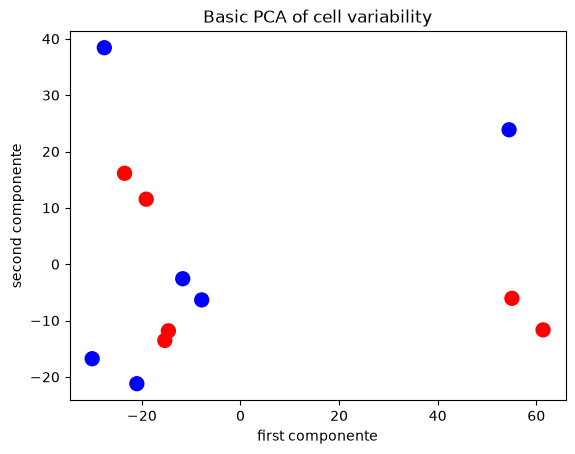

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#estandarizacion (media 0, varianza 1)
scaler=StandardScaler() 
X_esc=scaler.fit_transform(X_filt)

pca=PCA(n_components=2)
X_pca= pca.fit_transform(X_esc)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='bwr', s=100)
    #cmap='bwr': coloreara automaticamte los 0s en azul y los 1s en rojo
plt.title('Basic PCA of cell variability')
plt.xlabel('first componente')
plt.ylabel('second componente')
plt.show()

It can be observed that both groups are not perfectly separated. This is because PCA is an unsupervised technique; meaning, it does not know the label (color) of each data point and might not be grouping the cells based on their viability. Additionally, biology is complex, and senescence may not be explained by a clear-cut separation

Since linear separation (PCA) is not sufficient, we will use a supervised model (Random Forest)

**RANDOM FOREST**

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#division de datos: separamos un 30% de las células para poner a prueba el modelo al final
x_train, x_test, y_train, y_test= train_test_split(X_filt, y, test_size=0.3, random_state=42)
    #si pongo el 20% de 12 muestras= 2.4, entonces usaria solo 2 muestras para test (UN POCO LOCO)
    #si es el 30%= 3.6, entonces usaria 4 muestras (mas de variabilidad)
    #TODO: k-fold cross validation mejor, porque son poquitas muestras

modelo_rf=RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(x_train, y_train)

predicciones=modelo_rf.predict(x_test)

print("model's accuracy:", accuracy_score(y_test, predicciones))
print(classification_report(y_test, predicciones))

model's accuracy: 0.25
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      0.33      0.40         3

    accuracy                           0.25         4
   macro avg       0.25      0.17      0.20         4
weighted avg       0.38      0.25      0.30         4



Why is only a 25% accuracy obtained?

This is because there are still too many genes for so few samples (overfitting). Furthermore, out of the 4 test samples, 3 had high viability and only 1 had low viability. As a result, the model failed to predict the single senescent cell (0% accuracy) and only correctly predicted 1 out of the 3 young cells

We can solve this by using cross-validation instead of a simple train/test split. We will assume that with only 12 samples we will never achieve a perfect model, but we can leverage the Random Forest to extract the top 10 most important genes that the decision tree attempted to use

model's real accuracy: 91.66666666666666%


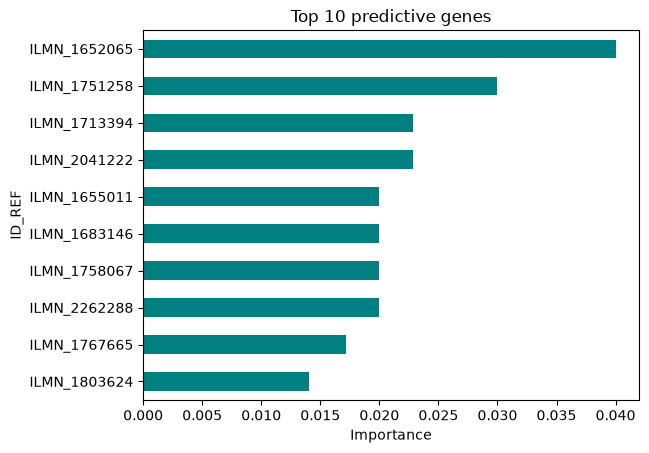

In [9]:
#leave-one-out cross-validation: entrena el modelo 12 veces distintas, apartando una celula diferente cada vez para examinarlo (k-fold con k=12)
from sklearn.model_selection import LeaveOneOut, cross_val_score

loo=LeaveOneOut()
precisiones= cross_val_score(modelo_rf, X_filt, y, cv=loo)
    #cv=loo: el programa divide automaticamte los datos
print(f"model's real accuracy: {precisiones.mean()*100}%")

#modelo final con todas las celulas para extraer cuales son los 10 genes mas importantes 
modelo_rf.fit(X_filt, y) #asi aprende lo maximo posible

importancias=pd.Series(modelo_rf.feature_importances_, index=X_filt.columns) 
    #el modelo guarda el peso matematico que le ha dado a cada gen en .feature_importances_ 
    #coge esos numeros y les pega al lado la etiqueta con el nombre del gen correspondiente (index=X_filt.columns)
    #crea una serie de pandas (lista ordenada)

top_10= importancias.nlargest(10)

plt.figure()
top_10.plot(kind='barh', color='teal')
plt.title('Top 10 predictive genes')
plt.xlabel('Importance')
plt.gca().invert_yaxis() #el gen mas importante arriba del todo
plt.show()